In [2]:
# Imports: data, numerics, plotting, vnstock API, and json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vnstock import register_user, Listing, Quote
import warnings
warnings.filterwarnings("ignore")
import json

📦 **Vnai 2.5.0 is available**
Current: 2.4.9 (Python 3.12)
Update: `pip install vnai --upgrade`
Release: https://pypi.org/project/vnai/#history

In [5]:
# Set plotting style and default figure size
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Register vnstock
register_user('vnstock_2d2225369316c09dd7eb5cb6e00a6a67')

✓ API key đã được lưu thành công! (API key saved successfully!)
Bạn đang sử dụng Phiên bản cộng đồng (60 requests/phút)
(You are using Community version - 60 requests/minute)

Để tham gia gói thành viên tài trợ (To join sponsor membership):
  Truy cập: https://vnstocks.com/insiders-program
✓ API key đã được lưu thành công! (✓ API key saved successfully! vnst***6a67
✓ Bạn đang sử dụng gói Cộng đồng (✓ You are using Community Edition - 60 requests/min)


True

In [ ]:
# Load VN30 membership changes and build full symbol universe
changes_df = pd.read_csv('../data/raw/vn30_membership_changes.csv', parse_dates=['effective_date'])

membership_symbols = changes_df['symbol'].dropna().unique().tolist()

current_vn30 = Listing().symbols_by_group('VN30')
full_universe = list(set(membership_symbols) | set(current_vn30))

print(f"Total unique symbols in the full universe: {len(full_universe)}")
print(sorted(full_universe))

Total unique symbols in the full universe: 51
['ACB', 'BCM', 'BID', 'BMP', 'BSR', 'BVH', 'CII', 'CTD', 'CTG', 'DGC', 'DHG', 'DPM', 'EIB', 'FPT', 'GAS', 'GMD', 'GVR', 'HDB', 'HPG', 'HSG', 'KDC', 'KDH', 'LPB', 'MBB', 'MSN', 'MWG', 'NVL', 'PDR', 'PLX', 'PNJ', 'POW', 'REE', 'ROS', 'SAB', 'SBT', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TCH', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VPL', 'VRE']


In [ ]:
# Fetch historical daily data for a list of symbols
def fetch_historical_data(symbols, start_date='2019-01-01', end_date='2026-07-01'):
    all_data = []
    failed_symbols = []

    for sym in symbols:
        try:
            # Request history from vnstock Quote using KBS source
            stock_obj = Quote(symbol=sym, source='KBS')
            df = stock_obj.history(start=start_date, end=end_date, interval='d')

            if df is not None and not df.empty:
                df['symbol'] = sym
                all_data.append(df)
                print(f"Successfully fetched data for {sym} ({len(df)} lines)")
            else:
                failed_symbols.append(sym)
        except Exception as e:
            print(f"Failed to fetch data for {sym}: {e}")
            failed_symbols.append(sym)
    
    # Combine all fetched DataFrames into one
    raw_prices = pd.concat(all_data, ignore_index=True)

    if failed_symbols:
        print(f"\nFailed to fetch data for the following symbols: {failed_symbols}")
        print("Common reasons: The stock has been delisted (e.g., ROS) or changed its ticker symbol.")
    
    return raw_prices

# Fetch for the full universe built earlier
df_raw = fetch_historical_data(full_universe)

# Save raw prices to CSV
df_raw.to_csv('../data/raw/vn30_all_prices_raw.csv', index=False)

Successfully fetched data for LPB (1859 lines)
Successfully fetched data for TPB (1869 lines)
Successfully fetched data for EIB (1869 lines)
Successfully fetched data for VIC (1869 lines)
Successfully fetched data for GAS (1869 lines)
Successfully fetched data for STB (1869 lines)
Successfully fetched data for PNJ (1869 lines)
Successfully fetched data for POW (1861 lines)
Successfully fetched data for VCB (1869 lines)
Successfully fetched data for BCM (1859 lines)
Successfully fetched data for PDR (1869 lines)
Successfully fetched data for SBT (1869 lines)
Successfully fetched data for VIB (1862 lines)
Successfully fetched data for REE (1869 lines)
Successfully fetched data for SSB (1315 lines)
Successfully fetched data for SAB (1869 lines)
Successfully fetched data for DHG (1869 lines)
Successfully fetched data for HDB (1869 lines)
Successfully fetched data for SSI (1869 lines)
Successfully fetched data for PLX (1869 lines)
Successfully fetched data for BVH (1869 lines)


Successfully fetched data for VNM (1869 lines)
Successfully fetched data for VRE (1869 lines)
Successfully fetched data for KDH (1869 lines)
Successfully fetched data for ROS (34 lines)
Successfully fetched data for GMD (1869 lines)
Successfully fetched data for MBB (1869 lines)
Successfully fetched data for VPB (1869 lines)
Successfully fetched data for ACB (1864 lines)
Successfully fetched data for TCH (1869 lines)
Successfully fetched data for DPM (1869 lines)
Successfully fetched data for BSR (1861 lines)
Successfully fetched data for VHM (1869 lines)
Successfully fetched data for BID (1869 lines)
Successfully fetched data for HPG (1869 lines)
Successfully fetched data for MWG (1869 lines)
Successfully fetched data for SHB (1866 lines)
Successfully fetched data for VPL (285 lines)
Successfully fetched data for CTD (1869 lines)
Successfully fetched data for VJC (1869 lines)
Successfully fetched data for CII (1869 lines)
Successfully fetched data for BMP (1869 lines)
Successfully fet

In [ ]:
# Load raw prices, pivot to wide, and report missing data rates
df_raw = pd.read_csv('../data/raw/vn30_all_prices_raw.csv')
df_raw['time'] = pd.to_datetime(df_raw['time'])

# Create time x symbol pivot of close prices
prices_pivot = df_raw.pivot(index='time', columns='symbol', values='close')

# Percent missing per symbol before fill
missing_rate = prices_pivot.isna().mean() * 100
missing_rate_sorted = missing_rate[missing_rate > 0].sort_values(ascending=False)
print("Codes with a missing data rate > 0%:")
print(missing_rate_sorted)

prices_pivot_raw = prices_pivot.copy()
# Forward-fill up to 5 days to reduce gaps
prices_pivot = prices_pivot_raw.ffill(limit=5)

missing_after_fill = prices_pivot.isna().mean() * 100
missing_after_fill_sorted = missing_after_fill[missing_after_fill > 0].sort_values(ascending=False)
print("\nCodes STILL missing after ffill(limit=5):")
print(missing_after_fill_sorted)

Codes with a missing data rate > 0%:
symbol
ROS    98.180845
VPL    84.751204
SSB    29.641520
BCM     0.535045
LPB     0.535045
POW     0.428036
BSR     0.428036
VIB     0.374532
GVR     0.321027
DGC     0.321027
ACB     0.267523
SHB     0.160514
dtype: float64

Codes STILL missing after ffill(limit=5):
symbol
ROS    97.485286
VPL    84.751204
SSB    29.641520
POW     0.428036
LPB     0.267523
BSR     0.160514
BCM     0.107009
VIB     0.107009
DGC     0.053505
GVR     0.053505
dtype: float64


In [ ]:
# Compute daily log returns and flag extreme daily moves
log_returns = np.log(prices_pivot / prices_pivot.shift(1))

log_returns = log_returns.dropna(how='all')

# Count large daily moves (>30%) per symbol
outliers = log_returns[(log_returns > 0.3) | (log_returns < -0.3)].count()
outliers = outliers[outliers > 0]

if not outliers.empty:
    print("WARNING: Unusual profit fluctuations (>30%/day) detected in the following stocks:")
    print(outliers)
    print("You should note this in the Limitations section of the report.")

In [ ]:
# Build point-in-time VN30 membership history from membership changes
def build_point_in_time_portfolio(current_list, changes_df):
    """
    Rebuild the data backward from the present to the past to obtain the VN30 list that is effective 
    FROM the date of change until before the next review period.
    """
    changes_df = changes_df.copy()
    # Normalize symbol strings
    changes_df['symbol'] = changes_df['symbol'].astype(str).str.strip().str.upper()
    current_list = [str(s).strip().upper() for s in current_list]

    # Keep only ADD/REMOVE actions and iterate from newest to oldest
    valid_changes = changes_df[changes_df['action'].isin(['ADD', 'REMOVE'])].copy()
    valid_changes = valid_changes.sort_values('effective_date', ascending=False)

    membership_history = {}
    running_set = set(current_list)

    lastest_date = valid_changes['effective_date'].max()
    membership_history[lastest_date] = running_set.copy()

    for date in valid_changes['effective_date'].unique():
        membership_history[date] = running_set.copy()

        period_changes = valid_changes[valid_changes['effective_date'] == date]
        for _, row in period_changes.iterrows():
            sym = row['symbol']
            if row['action'] == 'ADD':
                # Undo ADD when rebuilding backward
                if sym not in running_set:
                    print(f"WARNING at {date.date()}: ADD {sym} but not visible in ",
                          f"running_set before undo — check this symbol in the original file.")
                running_set.discard(sym)
            elif row['action'] == 'REMOVE':
                # Undo REMOVE when rebuilding backward
                if sym in running_set:
                    print(f"WARNING at {date.date()}: REMOVE {sym} but already AVAILABLE in ",
                          f"running_set before undo — may be duplicated or logically incorrect.")
                running_set.add(sym)
    
    return dict(sorted(membership_history.items()))

# Build PIT membership and show snapshot counts
pit_membership = build_point_in_time_portfolio(current_vn30, changes_df)

print("\nSnapshot of the number of codes in the basket over the periods:")
for date, symbols in pit_membership.items():
    print(f"{date.date()}: {len(symbols)} codes")


Snapshot of the number of codes in the basket over the periods:
2019-02-11: 30 codes
2019-08-05: 30 codes
2020-02-03: 30 codes
2020-08-03: 30 codes
2021-02-01: 30 codes
2021-08-02: 30 codes
2022-08-01: 30 codes
2023-02-06: 30 codes
2023-08-07: 30 codes
2025-02-03: 30 codes
2025-08-04: 30 codes
2026-02-02: 30 codes
2026-05-13: 30 codes


In [ ]:
# Save processed price and returns files and PIT membership JSON
prices_pivot.to_csv('../data/processed/vn30_prices_processed.csv', index=True)
log_returns.to_csv('../data/processed/vn30_log_returns_processed.csv', index=True)

pit_json_ready = {str(k.date()): list(v) for k, v in pit_membership.items()}

with open('../data/processed/vn30_membership_point_in_time.json', 'w') as f:
    json.dump(pit_json_ready, f, indent=4)

print("\nData collection and processing completed successfully. Processed files saved in the 'data/processed' directory.")


Data collection and processing completed successfully. Processed files saved in the 'data/processed' directory.


In [8]:
# Retrieve VN30 index's historical data
vn30_index_df = Quote(symbol='VN30', source='VCI').history(
    start='2019-01-01', end='2026-07-01', interval='D')

vn30_index_df['time'] = pd.to_datetime(vn30_index_df['time'])
vn30_index_df = vn30_index_df.set_index('time')
vn30_index_df = vn30_index_df.loc['2019-01-01':'2026-07-01']
print(vn30_index_df.tail())

vn30_index_df.to_csv('../data/raw/vn30_index_raw.csv', index=True)

               open     high      low    close     volume
time                                                     
2026-06-25  2013.14  2015.06  1998.39  2004.62  230753501
2026-06-26  1999.69  2009.27  1989.59  2008.57  224676827
2026-06-29  2006.25  2009.73  1999.83  2004.29  259459741
2026-06-30  2003.46  2007.22  1990.47  1995.71  312451165
2026-07-01  1996.71  2016.64  1996.71  2013.35  346105354


In [9]:
index_raw_path = '../data/raw/vn30_index_raw.csv'
df_index_raw = pd.read_csv(index_raw_path)

df_index_raw['time'] = pd.to_datetime(df_index_raw['time'])
df_index = df_index_raw.set_index('time')

df_index_close = df_index[['close']].copy()
df_index_close.rename(columns={'close': 'VN30_Index'}, inplace=True)

missing_rate = df_index_close.isna().mean() * 100
missing_rate_sorted = missing_rate[missing_rate > 0].sort_values(ascending=False)
print("Codes with a missing data rate > 0%:")
print(missing_rate_sorted)

df_index_close = df_index_close.ffill(limit=5)

missing_after_fill = df_index_close.isna().mean() * 100
missing_after_fill_sorted = missing_after_fill[missing_after_fill > 0].sort_values(ascending=False)
print("\nCodes STILL missing after ffill(limit=5):")
print(missing_after_fill_sorted)

Codes with a missing data rate > 0%:
Series([], dtype: float64)

Codes STILL missing after ffill(limit=5):
Series([], dtype: float64)


In [10]:
processed_path = '../data/processed/vn30_index_processed.csv'
df_index_close.to_csv(processed_path, index=True)
print(df_index_close.head())

            VN30_Index
time                  
2019-01-02      855.66
2019-01-03      838.79
2019-01-04      840.17
2019-01-07      851.41
2019-01-08      845.43


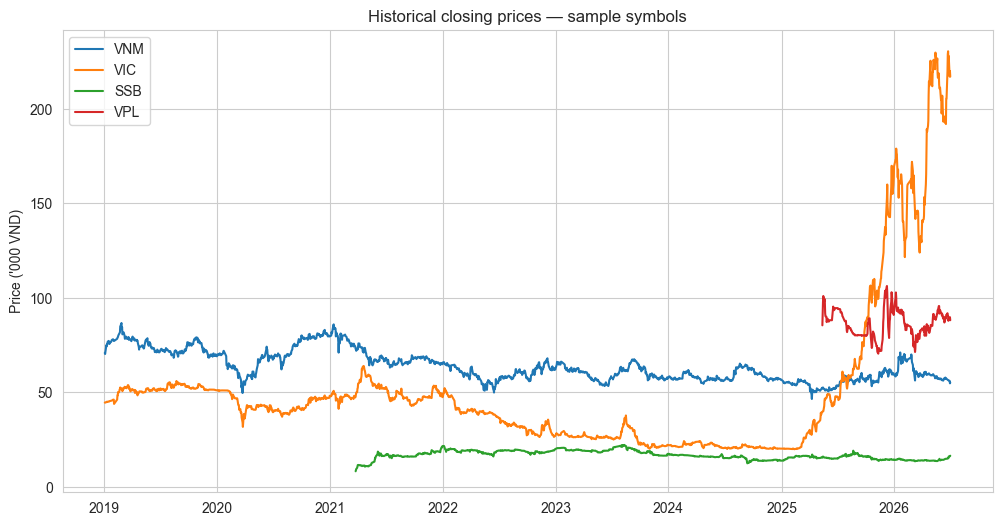

In [ ]:
# Plot sample historical closing prices for a few symbols
fig, ax = plt.subplots(figsize=(12, 6))
sample_symbols = ['VNM', 'VIC', 'SSB', 'VPL']
for sym in sample_symbols:
    ax.plot(prices_pivot.index, prices_pivot[sym], label=sym)
ax.legend()
ax.set_title('Historical closing prices - sample symbols')
ax.set_ylabel("Price ('000 VND)")
plt.show()

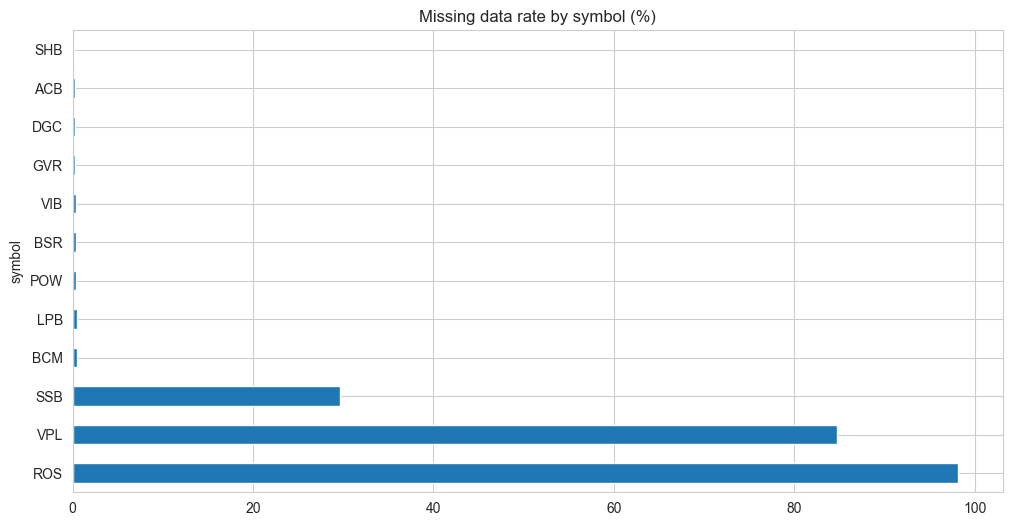

In [ ]:
# Plot missing data rate per symbol
fig, ax = plt.subplots(figsize=(12, 6))
missing_rate_sorted.plot(kind='barh', ax=ax)
ax.set_title('Missing data rate by symbol (%)')
plt.show()

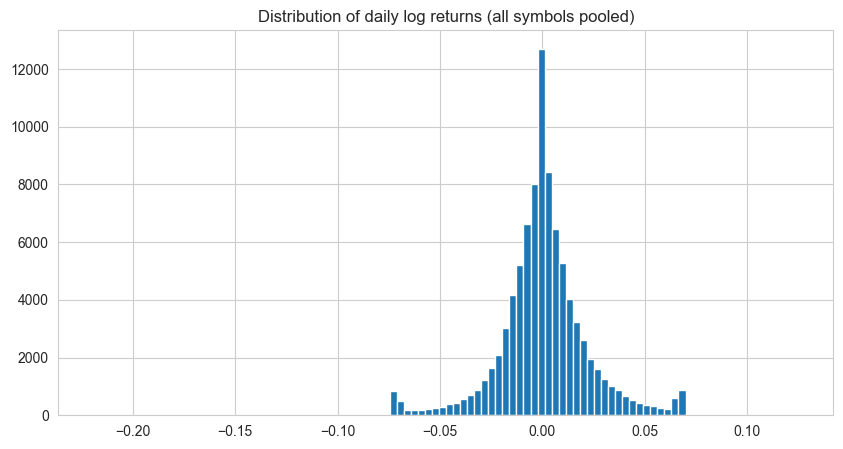

In [ ]:
# Histogram of pooled daily log returns across all symbols
fig, ax = plt.subplots(figsize=(10, 5))
log_returns.stack().hist(bins=100, ax=ax)
ax.set_title('Distribution of daily log returns (all symbols pooled)')
plt.show()

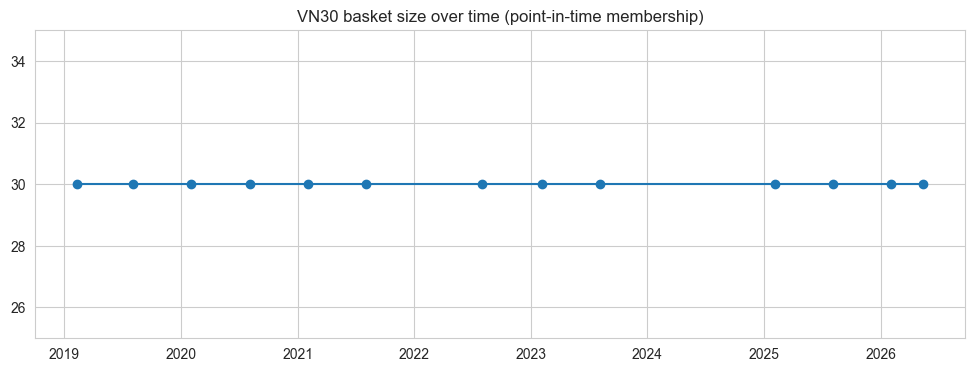

In [ ]:
# Plot VN30 basket size over time from PIT membership
dates = list(pit_membership.keys())
counts = [len(v) for v in pit_membership.values()]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, counts, marker='o')
ax.set_title('VN30 basket size over time (point-in-time membership)')
ax.set_ylim(25, 35)
plt.show()